# Groups, Rings, Fields — the Ladder of Algebraic Structure

"Numbers and operators" is really a hierarchy. Each rung adds a guarantee:

| structure | operations | what you gain |
|---|---|---|
| **group** | one ($\cdot$) | closure, identity, *inverses* (you can undo) |
| **abelian group** | one, commutative | order doesn't matter |
| **ring** | two ($+,\,\cdot$) | add *and* multiply, with distributivity |
| **field** | two, every nonzero invertible | you can **divide** |

The axioms are finite and checkable, so this notebook *verifies* them by brute force rather than
asserting. The examples are the repo's own: $\mathbb Z/26$ (the ring behind the ROT cipher),
$\mathrm{GF}(p)$ (the fields behind coding/crypto), and the parity group $\{+1,-1\}$ from Griffiths
1.10. Engine: `algebra.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import algebra as al

def show_cayley(ax, elements, op, labels=None, title=""):
    raw = [[op(a, b) for b in elements] for a in elements]
    if all(isinstance(e, int) for e in elements):
        tab = np.array(raw)              # raw values: shows escapes (zero divisors)
    else:
        idx = {e: i for i, e in enumerate(elements)}   # permutations: index by element
        tab = np.array([[idx[v] for v in row] for row in raw])
    ax.imshow(tab, cmap="twilight", aspect="equal")
    labels = labels or [str(e) for e in elements]
    ax.set_xticks(range(len(elements))); ax.set_yticks(range(len(elements)))
    ax.set_xticklabels(labels, fontsize=7); ax.set_yticklabels(labels, fontsize=7)
    for i in range(len(elements)):
        for j in range(len(elements)):
            ax.text(j, i, tab[i, j], ha="center", va="center", fontsize=6, color="w")
    ax.set_title(title, fontsize=10)
print("algebra.py loaded")

algebra.py loaded


## §1 Group: one operation you can undo

$\mathbb Z/n$ under addition is the cyclic group $C_n$: add and wrap. Its Cayley table is a Latin
square with the tell-tale diagonal stripes of a cyclic group — every row is the previous one shifted.

Z/5 under +: group? True  abelian? True
Z/6 under +: group? True  abelian? True
Z/26 under +: group? True  abelian? True


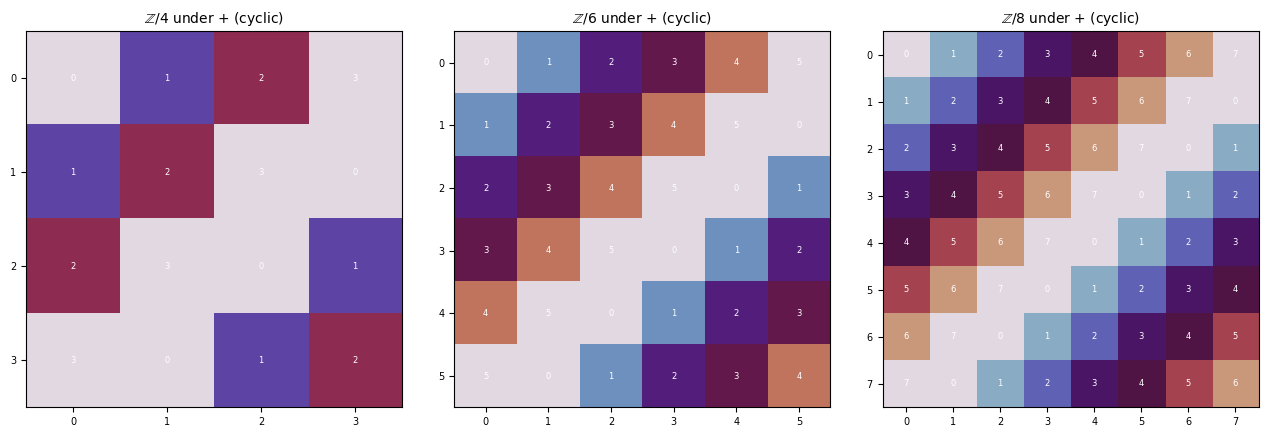

In [2]:
for n in (5, 6, 26):
    print(f"Z/{n} under +: group? {al.is_group(al.Zn(n), al.add_mod(n))}  "
          f"abelian? {al.is_abelian_group(al.Zn(n), al.add_mod(n))}")

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, n in zip(ax, (4, 6, 8)):
    show_cayley(a, al.Zn(n), al.add_mod(n), title=f"$\\mathbb{{Z}}/{n}$ under + (cyclic)")
plt.tight_layout(); plt.show()

## §2 Abelian or not: does order matter?

$\mathbb Z/n$ is **abelian** — its Cayley table is symmetric across the diagonal. The symmetric group
$S_3$ (all reorderings of three objects, = the symmetries of a triangle) is the smallest
**non-abelian** group: its table is *not* symmetric, because doing two operations in the other order
gives a different result. The parity group $\{+1,-1\}$ from Griffiths 1.10 is $\cong\mathbb Z/2$.

S_3: group? True  abelian? False
parity group {+1,-1}: abelian group? True  ~ Z/2


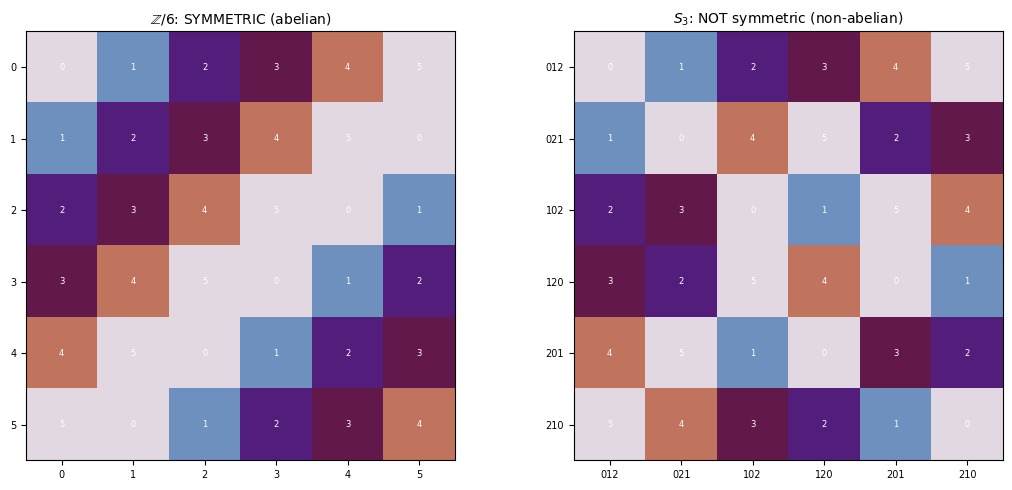

In [3]:
S3 = al.symmetric_group(3)
print(f"S_3: group? {al.is_group(S3, al.compose)}  abelian? {al.is_abelian_group(S3, al.compose)}")
pe, pop = al.parity_group()
print(f"parity group {{+1,-1}}: abelian group? {al.is_abelian_group(pe, pop)}  ~ Z/2")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
show_cayley(ax[0], al.Zn(6), al.add_mod(6), title="$\\mathbb{Z}/6$: SYMMETRIC (abelian)")
show_cayley(ax[1], S3, al.compose, labels=[''.join(map(str, p)) for p in S3],
            title="$S_3$: NOT symmetric (non-abelian)")
plt.tight_layout(); plt.show()

## §3 Ring: add *and* multiply

Give the set a second operation that distributes over the first and you have a **ring**. $\mathbb Z/n$
is the canonical example — and $\mathbb Z/26$ is precisely the ring the **ROT/Caesar cipher** lives in
(`rot_ciphers_unicity.ipynb`): encryption is $+k$, the additive group; a multiplicative (affine)
cipher uses the ring's $\times$.

Z/5: ring? True
Z/6: ring? True
Z/26: ring? True

Z/26 is the ROT-cipher ring: + is the Caesar shift, x enables affine ciphers.


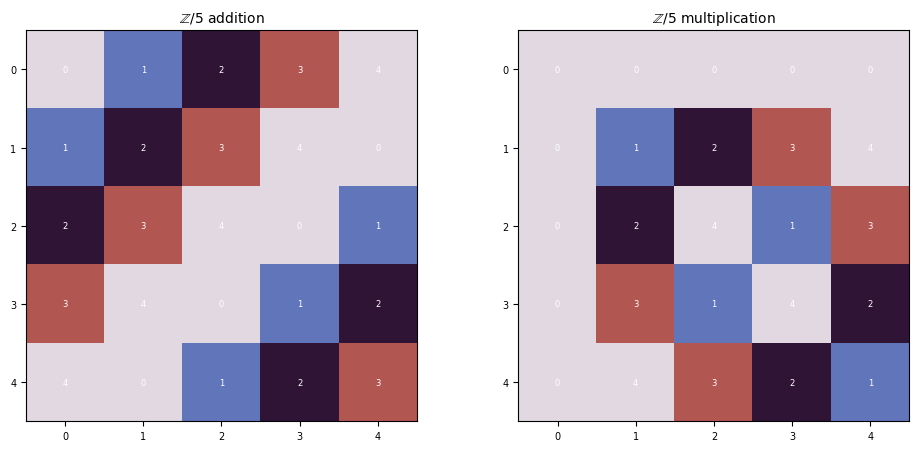

In [4]:
for n in (5, 6, 26):
    print(f"Z/{n}: ring? {al.is_ring(al.Zn(n), al.add_mod(n), al.mul_mod(n))}")
print("\nZ/26 is the ROT-cipher ring: + is the Caesar shift, x enables affine ciphers.")

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
show_cayley(ax[0], al.Zn(5), al.add_mod(5), title="$\\mathbb{Z}/5$ addition")
show_cayley(ax[1], al.Zn(5), al.mul_mod(5), title="$\\mathbb{Z}/5$ multiplication")
plt.tight_layout(); plt.show()

## §4 Field: now you can divide

A **field** is a ring where every nonzero element has a multiplicative inverse — so division works.
The clean theorem, *verified* below: $\mathbb Z/n$ is a field **exactly when $n$ is prime**. When $n$
is composite it has **zero divisors** (e.g. $2\cdot3=0$ in $\mathbb Z/6$), which can't be inverted.

Z/n is a field for n = [2, 3, 5, 7, 11, 13, 17, 19]
primes up to 20      = [2, 3, 5, 7, 11, 13, 17, 19]
identical? True  -> Z/n is a field iff n is prime

zero divisor in Z/6: 2 * 3 = 0 (mod 6) -> 2 and 3 have no inverse


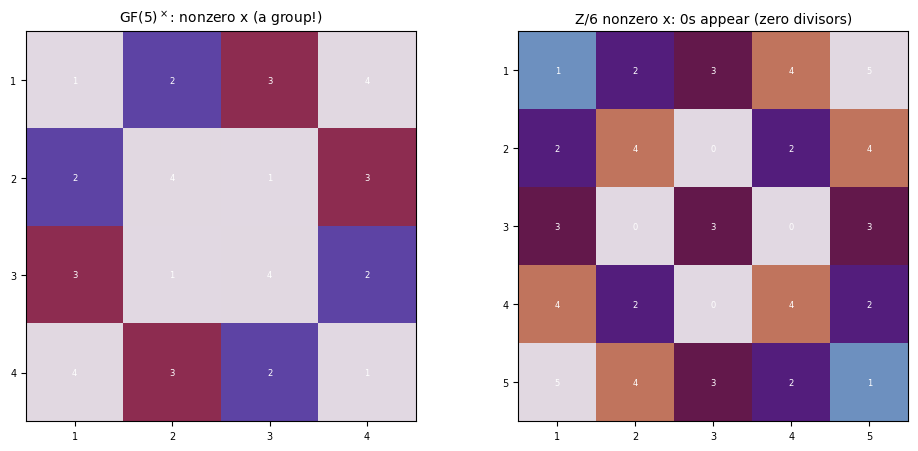

In [5]:
fields = [n for n in range(2, 20) if al.is_field(al.Zn(n), al.add_mod(n), al.mul_mod(n))]
primes = [n for n in range(2, 20) if al.is_prime(n)]
print("Z/n is a field for n =", fields)
print("primes up to 20      =", primes)
print("identical?", fields == primes, " -> Z/n is a field iff n is prime")
print("\nzero divisor in Z/6: 2 * 3 =", al.mul_mod(6)(2, 3), "(mod 6) -> 2 and 3 have no inverse")

# the GF(5) multiplication table on NONZERO elements is a Latin square (a group)
fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
show_cayley(ax[0], [1, 2, 3, 4], al.mul_mod(5), title="GF(5)$^\\times$: nonzero x (a group!)")
show_cayley(ax[1], [1, 2, 3, 4, 5], al.mul_mod(6), title="Z/6 nonzero x: 0s appear (zero divisors)")
plt.tight_layout(); plt.show()

## §5 The ladder, and where each rung lands

- **Groups $\to$ symmetry.** Every symmetry is a group: the parity group $\{1,P\}$ whose eigenvalues
  $\pm1$ are Griffiths' pseudovector signs; the rotation groups $SO(2),SO(3)$; and (Noether) every
  continuous symmetry a conservation law. Group theory *is* the language of physics symmetry.
- **Rings $\to$ modular arithmetic & ciphers.** $\mathbb Z/26$ is the ROT-cipher ring; $\mathbb Z/2^{n}$
  is machine integer arithmetic (overflow = wrapping in a ring). Polynomials form rings — the home of
  the FFT's cousin, the number-theoretic transform.
- **Fields $\to$ coding, crypto, computation.** $\mathrm{GF}(2)$ underlies every binary error-correcting
  code; $\mathrm{GF}(p)$ and $\mathrm{GF}(2^m)$ run Reed-Solomon (CDs, QR codes, deep-space links) and
  the number-theoretic transform that does exact integer convolution. "You can divide" is exactly what
  Gaussian elimination, interpolation, and the discrete log (crypto) all need.
- **The moral.** More axioms = more leverage. A group lets you undo; a ring lets you build polynomials;
  a field lets you solve linear systems. Knowing the minimal structure a problem needs tells you which
  tools are even available.

Engine added this session: `algebra.py` (axiom checkers, Cayley tables, $\mathbb Z/n$, $S_n$, parity
group, $\mathrm{GF}(p)$), benchmarked in `scripts/smoke_algebra.py`.